# Day 08：文字的预言家 —— 用 LSTM 生成文本> ⏳ 第十周 · 记忆的诞生 · 第 8 天今天，我们要让 LSTM 做一件很酷的事：**自动生成文本**。给 LSTM 一段开头，它会一个字一个字地"续写"下去。这就像一个学会了语言规律的"文字预言家"。**今天的任务**：1. 理解文本生成的原理：逐字预测2. 用 LSTM 训练一个字符级语言模型3. 用不同的"温度"控制生成的创造性---

## 1. 历史剧场：从"鹦鹉学舌"到"AI 写作"2015 年，Andrej Karpathy 发表了著名的博客《The Unreasonable Effectiveness of Recurrent Neural Networks》。他训练了一个字符级 LSTM，给它输入莎士比亚的剧本，它就能生成"莎士比亚风格"的文字：> "KING RICHARD: What, is it not to be so much as a man..."虽然语法不完全正确，但风格、格式、甚至人物对话的模式都模仿得惟妙惟肖。这在当时引起了轰动。---

## 2. 生活隐喻：学会了"语感"的学生- **背课文的学生**：一字不差地复述——这是"过拟合"- **有语感的学生**：能写出风格相似但内容全新的句子——这是"泛化"LSTM 文本生成就是学会了"语感"：它不是死记硬背训练文本，而是学会了字符出现的概率模式。---

<p align="center">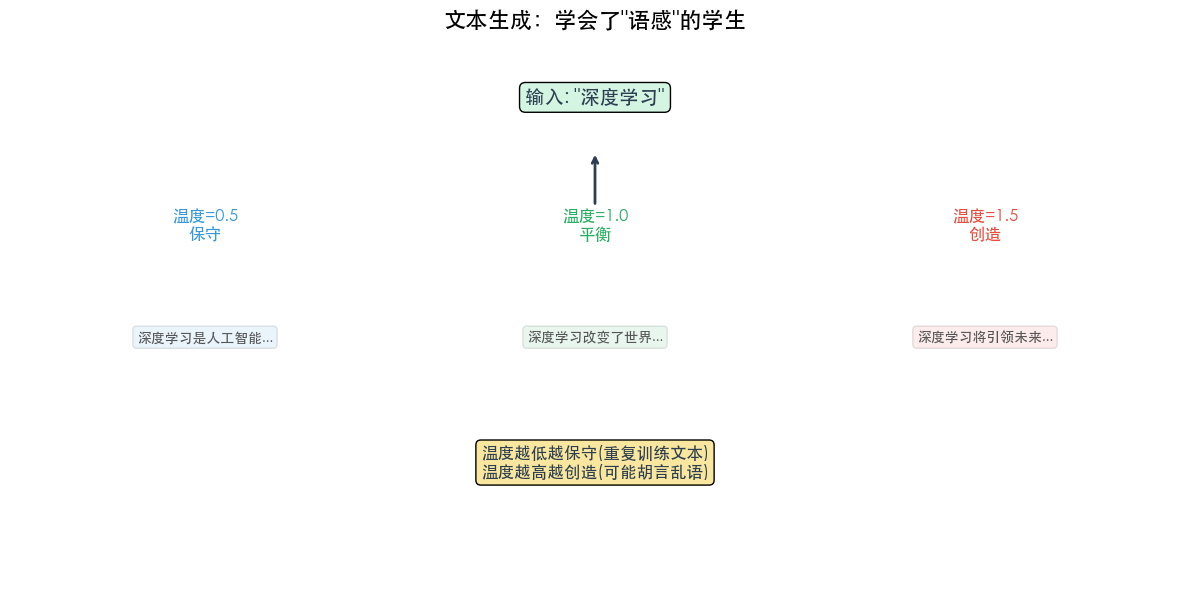</p>*文本生成温度控制示意图*

## 3. 代码实验室：字符级文本生成

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.1 准备训练文本

In [ ]:
text = """深度学习是人工智能的核心技术它让计算机能够从数据中学习神经网络是深度学习的基础从感知机到卷积网络再到循环网络循环神经网络能够处理序列数据它拥有记忆可以理解上下文长短期记忆网络解决了梯度消失的问题它有三个门控机制遗忘门决定忘记什么输入门决定记住什么输出门决定输出什么门控循环单元是长短期记忆的简化版本它只有两个门深度学习改变了世界从图像识别到自然语言处理人工智能的未来充满希望深度学习将继续引领技术革命"""chars = sorted(list(set(text)))char_to_idx = {c: i for i, c in enumerate(chars)}idx_to_char = {i: c for c, i in char_to_idx.items()}vocab_size = len(chars)print(f"文本长度: {len(text)} 字符")print(f"词汇表大小: {vocab_size}")print(f"词汇表: {''.join(chars)}")

### 3.2 构建训练数据

In [ ]:
seq_length = 10X_data, y_data = [], []for i in range(len(text) - seq_length):    X_data.append([char_to_idx[c] for c in text[i:i+seq_length]])    y_data.append(char_to_idx[text[i+seq_length]])X_tensor = torch.tensor(X_data, dtype=torch.long)y_tensor = torch.tensor(y_data, dtype=torch.long)print(f"训练样本数: {len(X_data)}")print(f"示例: '{text[:seq_length]}' → 预测 '{text[seq_length]}'")

### 3.3 定义 LSTM 语言模型

In [ ]:
class CharLSTM(nn.Module):    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2):        super().__init__()        self.hidden_dim = hidden_dim        self.num_layers = num_layers        self.embedding = nn.Embedding(vocab_size, embed_dim)        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,                           batch_first=True, dropout=0.1)        self.fc = nn.Linear(hidden_dim, vocab_size)    def forward(self, x, hidden=None):        emb = self.embedding(x)        out, hidden = self.lstm(emb, hidden)        out = self.fc(out[:, -1, :])        return out, hiddentorch.manual_seed(42)model = CharLSTM(vocab_size, embed_dim=32, hidden_dim=128, num_layers=2)total_params = sum(p.numel() for p in model.parameters())print(f"模型参数量: {total_params:,}")

### 3.4 训练模型

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)loss_fn = nn.CrossEntropyLoss()losses = []for epoch in range(500):    out, _ = model(X_tensor)    loss = loss_fn(out, y_tensor)    optimizer.zero_grad()    loss.backward()    nn.utils.clip_grad_norm_(model.parameters(), 1.0)    optimizer.step()    losses.append(loss.item())    if (epoch + 1) % 100 == 0:        print(f"Epoch {epoch+1:4d} | Loss: {loss.item():.4f}")

### 3.5 文本生成函数

In [ ]:
def generate_text(model, start_text, length=50, temperature=1.0):    model.eval()    hidden = None    current = [char_to_idx[c] for c in start_text]    for _ in range(length):        x = torch.tensor([current[-seq_length:]], dtype=torch.long)        with torch.no_grad():            out, hidden = model(x, hidden)            logits = out[0] / temperature            probs = torch.softmax(logits, dim=0).numpy()        next_idx = np.random.choice(vocab_size, p=probs)        current.append(next_idx)    return ''.join(idx_to_char[i] for i in current)print("温度=0.5 (保守):")print(generate_text(model, "深度学习", length=30, temperature=0.5))print()print("温度=1.0 (平衡):")print(generate_text(model, "深度学习", length=30, temperature=1.0))print()print("温度=1.5 (创造):")print(generate_text(model, "深度学习", length=30, temperature=1.5))

### 3.6 可视化：温度对生成的影响

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))ax.plot(losses, color='#3498db', alpha=0.8)ax.set_xlabel('Epoch', fontsize=12)ax.set_ylabel('Loss', fontsize=12)ax.set_title('LSTM 语言模型训练损失', fontsize=14)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

---

## 4. 温度的直觉| 温度 | 效果 | 直觉 ||---|---|---|| 0.1 | 几乎重复训练文本 | 好学生——只写学过的 || 0.5 | 保守但合理 | 稳重学生——偶尔创新 || 1.0 | 平衡 | 正常学生——有学有创 || 1.5 | 创造但有风险 | 文艺学生——天马行空 || 2.0 | 乱七八糟 | 疯学生——胡言乱语 |温度控制的是 softmax 输出的"尖锐度"：温度越低，概率越集中在最高概率的字符上；温度越高，概率越平均，选择更随机。---

## 今日结语今天我们让 LSTM 学会了"语感"——给它一段开头，它能续写出风格相似的新文本。文本生成的核心是**逐字预测**：每一步，LSTM 根据之前的字符预测下一个字符的概率分布，然后从中采样。温度参数控制了生成的保守/创造程度。明天，我们将学习 LSTM 的另一个重要应用：序列到序列模型。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 学会了语感 | 语言模型——学习字符出现的概率模式 || 逐字续写 | 自回归生成——每步预测下一个字符 || 保守 vs 创造 | 温度参数——控制 softmax 的尖锐度 || 好学生 vs 文艺学生 | 低温 vs 高温——重复训练文本 vs 天马行空 |